# **Mestrado em Ciência de Dados - 2.º Ano**
**Aluno:** Miguel Loureiro | 2220134

**Instituição:** Universidade de Leiria e Oeste  

***Dissertação:*** Data Mining Aplicado à Transformação Digital de uma PME Portuguesa de E-commerce: Um Caso de Estudo Integrado

---

# **Notebook 8. Regras de Associação | Apriori - Produtos Comprados em Conjunto**
*O presente notebook envolve a componente de regras de associação aplicada à identificação de produtos comprados em conjunto pelos clientes da PME em estudo.*

---

## **Contextualização do problema em estudo**

### **Problema de negócio**

Identificar padrões de compra conjunta de produtos do catálogo da empresa com o objetivo de auxiliar na definição de estratégias de cross-sell, na criação de bundles / packs de produto e na otimização das páginas de produto ao exibir uma secção personalizada de "frequentemente comprados em conjunto".

### **Formulação do problema de Associação**

**Tarefa:** Identificação de regras de associação do tipo *"se o cliente compra produto A, então também compra produto B"* sobre todo o histórico transacional da empresa, tirando partido da avaliação de três métricas sustentadas pela literatura (Support, Confidence, Lift).

**Dimensão:** Conjunto completo das 55.971 transações registadas entre 13 de fevereiro de 2016 e 31 de março de 2026 (~10 anos de histórico).

**Granularidade:** Cada transação é definida como o conjunto dos produtos únicos presentes numa venda, sendo identificada pela variável `Ref Venda`. Esta abordagem permite que cada venda seja tratada como um carrinho, ignorando as quantidades adquiridas.

**Métricas principais:**

- **Support** - frequência relativa da ocorrência conjunta.
- **Confidence** - probabilidade de B estar incluído numa transação que contém A.
- **Lift** - força mínima da associação em relação ao acaso.

### **Algoritmo aplicado**

| Algoritmo | Tipo | Justificação |
|---|---|---|
| **Apriori** | Frequent itemset mining + association rules | Algoritmo de referência para regras de associação. Adequado a datasets transacionais de dimensão média como o presente (55.971 transações × 5.723 produtos únicos). |

### **Caracterização do notebook**

O presente notebook é o primeiro de dois notebooks que englobam o desenvolvimento da componente de regras de associação. Neste notebook é aplicado o algoritmo Apriori ao histórico transacional completo da empresa, resultando na descoberta de um conjunto de regras que dão a conhecer padrões compra conjunta. No próximo notebook (NB9) será aplicado o mesmo algoritmo, no entanto num horizonte temporal diferente (apenas nos últimos 12 meses), possibilitando a realização de uma análise temporal comparativa e a identificação de regras persistentes, emergentes e descontinuadas.

### **Boas práticas adotadas**

- **Limitação a pares** - simplifica a interpretação operacional ("se o cliente compra A, então também compra B").
- **Normalização dos nomes dos produtos** com `fillna + strip` - trata as variações textuais associadas ao mesmo produto, como por exemplo espaços nas extremidades.
- **Análise de sensibilidade ao limite de Support** - valida a robustez dos resultados explorando um limite menos restritivo (0,0005).

---

## **Estrutura do notebook**

1. Instalação e importação de bibliotecas
2. Carregamento dos dados
3. Construção das transações
4. Análise exploratória das transações
5. Determinação dos parâmetros do Apriori
6. Treino do modelo Apriori
7. Visualização dos resultados
8. Dataframe com regras ordenadas
9. Análise de sensibilidade
10. Síntese

### **Outputs deste notebook**

- 27 regras que cumprem os três critérios mínimos.
- DataFrame `resultsinDataFrame` com as regras ordenadas, que será utilizado no próximo notebook para a análise temporal comparativa.


## **1. Instalação e importação de bibliotecas**

Este notebook inicia-se com a instalação da biblioteca `apyori`, que permite a implementação do algoritmo Apriori. Adicionalmente, são importadas as restantes bibliotecas essenciais à análise. A biblioteca `apyori` não vem pré-instalada no Google Colab, pelo que é essencial a sua instalação na primeira execução do notebook.

In [1]:
#Instalar a biblioteca apyori (necessária apenas na primeira execução)
#apyori é uma implementação standalone do algoritmo Apriori, adequada a datasets desta dimensão
!pip install apyori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5996 sha256=6906d9e1ffe2a03c9c4b7afcaa63067850049aa6a33a62dcac76f21c5e77fc77
  Stored in directory: /root/.cache/pip/wheels/4d/9f/d0/7ba4ae3f5de2f76ea362170ea0f157e6cc1d1b9aea188175f2
Successfully built apyori


In [2]:
#Importação das bibliotecas essenciais
import pandas as pd                #estruturação tabular dos dados
import numpy as np                 #operações numéricas
import matplotlib.pyplot as plt    #visualização
from apyori import apriori         #algoritmo de mineração de regras de associação
from collections import Counter    #contagem de frequências de itens

## **2. Carregamento dos dados**

O carregamento dos dados é realizado recorrendo ao dataframe, criado e exportado no notebook de Compreensão de Dados, ao nível da linha de produto (`df_linhas`). Este dataset é composto por duas colunas de identificação de produto:

- **`Ref Produto`** - código interno composto por números
- **`Nome do Produto`** - nome legível

A escolha do `Nome do Produto` e não da `Ref Produto` é propositada, na medida em que torna a leitura das regras de associação possível sem cruzar com uma tabela de descrições à parte. Esta escolha acarreta um custo relacionado com as variações textuais associadas ao mesmo produto, que serão mitigadas neste notebook.

In [3]:
#Montar Drive e carregar o dataset transacional exportado pelo NB1
from google.colab import drive
drive.mount('/content/drive')

#Apriori trabalha ao nível da transação (venda)
df = pd.read_csv('/content/drive/MyDrive/df_linhas.csv')
df['Data'] = pd.to_datetime(df['Data'])

#Caracterização básica do dataset carregado
print(f'Dimensão do dataset: {df.shape}')
print(f'Período: {df["Data"].min().date()} a {df["Data"].max().date()}')
print(f'Número de vendas únicas: {df["Ref Venda"].nunique()}')
print(f'Número de produtos únicos: {df["Nome do Produto"].nunique()}')

Mounted at /content/drive
Dimensão do dataset: (152976, 18)
Período: 2016-02-13 a 2026-03-31
Número de vendas únicas: 55971
Número de produtos únicos: 8506


O carregamento dos dados demonstra a existência de 152.976 registos e 18 atributos, englobando 55.971 vendas distintas e um catálogo de 8.506 produtos únicos.

### **2.1. Normalização dos nomes de produto**

No decorrer da atividade da empresa desde a criação da loja online, podem existir atualizações da nomenclatura de um produto (`Nome do Produto`), mantendo uma `Ref Produto` estável. Estas alterações estão relacionadas com, por exemplo, substituição do separador - por », diferenças em 700Gr. vs 700Gr. Neste sentido, a aplicação de normalização do nome do produto, em cada `Ref Produto`, para a nomenclatura mais recente permite a aplicação do algoritmo Apriori sem que esta aplicação trate como pares distintos produtos que são iguais. Este processo é aplicado antes da construção das transações e será igualmente utilizado no NB9 para assegurar comparabilidade dos resultados.

In [4]:
#Normalização: para cada Ref Produto, adotar o Nome do Produto mais recente devido a variações na nomenclatura ao longo do tempo
#Processo coerente com a aplicação a ser feita no NB9 para garantir comparabilidade

mapa_normalizado = (
    df.sort_values('Data')
      .drop_duplicates('Ref Produto', keep='last')
      .set_index('Ref Produto')['Nome do Produto']
      .to_dict()
)

variacoes = df.groupby('Ref Produto')['Nome do Produto'].nunique()
n_com_variacoes = (variacoes > 1).sum()
print(f'Total de Ref Produto únicos:                {len(mapa_normalizado)}')
print(f'Ref Produto com variações de nome:          {n_com_variacoes}')
print(f'Percentagem de produtos com variações:      {n_com_variacoes/len(mapa_normalizado):.1%}')

df['Nome do Produto'] = df['Ref Produto'].map(mapa_normalizado)

Total de Ref Produto únicos:                5856
Ref Produto com variações de nome:          2145
Percentagem de produtos com variações:      36.6%


A análise aos resultados evidencia que existem 2.145 referências de produtos com alterações de nome e 36,6% produtos com variações registadas.

**Diagnóstico de qualidade do `Nome do Produto`**

Antes iniciar a construção das transações, é importante avaliar a qualidade dos dados incluídos na variável `Nome do Produto` para identificar variações textuais que devem ser alvo de tratamento. A análise abaixo permite avaliar o número de produtos distintos, os valores omissos na variável e a quantidade de pares de produtos que apresentam espaços nas extremidades.

In [5]:
#Comparar contagens de produtos únicos sob diferentes normalizações
print(f'Original (nunique):              {df["Nome do Produto"].nunique()}')
print(f'Após fillna:                     {df["Nome do Produto"].fillna("Desconhecido").nunique()}')
print(f'Após fillna + strip:             {df["Nome do Produto"].fillna("Desconhecido").str.strip().nunique()}')

#Identificar pares de produtos com variações apenas em espaços nas extremidades
nomes = df['Nome do Produto'].dropna().unique()
nomes_strip = pd.Series(nomes).str.strip()
duplicados_strip = nomes_strip[nomes_strip.duplicated(keep=False)].sort_values()

print(f'\nProdutos com variações de whitespace: {len(duplicados_strip)}')
print(f'\nExemplos (primeiros 20):')
for n in duplicados_strip.head(20).tolist():
    print(f'  "{n}"')

#Contar valores omissos
n_nan = df['Nome do Produto'].isna().sum()
print(f'\nValores NaN em Nome do Produto: {n_nan}')

Original (nunique):              5724
Após fillna:                     5724
Após fillna + strip:             5723

Produtos com variações de whitespace: 2

Exemplos (primeiros 20):
  "Óculos Panorâmicos Lente em Policabonato Incolor"
  "Óculos Panorâmicos Lente em Policabonato Incolor"

Valores NaN em Nome do Produto: 0


A análise realizada evidencia a inexistência de valores omissos na variável `Nome do Produto`, no entanto existem 2 registos em que se verificam espaços nas extremidades da designação do produto.

## **3. Construção das transações**

No processo de criação das transações, cada transação está associada a uma venda, ou seja, a uma `Ref Venda`, integrando o conjunto dos produtos únicos presentes nessa venda. A normalização dos nomes é feita através de `fillna + strip`, possibilitando remover os espaços nas extremidades de forma a consolidar as variações textuais do mesmo produto.

In [6]:
#Tratar valores em falta no nome do produto e normalizar espaços nas extremidades
#fillna('Desconhecido')  - qualquer NaN é tratado como uma categoria explícita
#str.strip()             - remove espaços nas extremidades (causa principal de variantes)
df['Nome do Produto'] = df['Nome do Produto'].fillna('Desconhecido').str.strip()

#Construir transações: para cada Ref Venda, lista dos produtos únicos comprados
#Usar .unique() dentro do groupby evita contar duas vezes o mesmo produto numa transação
transactions_series = df.groupby('Ref Venda')['Nome do Produto'].apply(lambda x: list(x.unique()))

print(f'Total de vendas (transações): {len(transactions_series)}')
print(f'\nPrimeiras 5 transações:')
print(transactions_series.head())

Total de vendas (transações): 55971

Primeiras 5 transações:
Ref Venda
7              [Papa Branca Húmida TH Lipo Soft » 12Kg]
8     [Comedouro Cristal c/Gaveta, Bebedouro Voadeir...
9     [Papa Branca Húmida TH Lipo Soft » 12Kg, Papa ...
10    [Bebedouro Automático Copo Balanço Entrada 12m...
11    [CHEMI-VIT - Victor Respiroil Liquido - 200ml,...
Name: Nome do Produto, dtype: object


De seguida, as transações construídas são convertidas para lista de strings, sendo um passo necessário para aplicação do algoritmo Apriori.

In [7]:
#Converter para lista de listas de strings (formato requerido pelo apyori)
transactions = transactions_series.tolist()

#Confirmar a estrutura através de exemplos
print(f'Exemplo das primeiras 3 transações:')
for i, t in enumerate(transactions[:3], 1):
    print(f'  Transação {i} ({len(t)} produto(s)): {t}')

Exemplo das primeiras 3 transações:
  Transação 1 (1 produto(s)): ['Papa Branca Húmida TH Lipo Soft » 12Kg']
  Transação 2 (12 produto(s)): ['Comedouro Cristal c/Gaveta', 'Bebedouro Voadeira 600ml', 'Psittacus - Alimento Manutenção Micro - 350Gr.', 'Art.83 - Ninho Plástico Periquitos', 'Ninho Periquitos  (Sem\xa0preferência)', 'Ninho Periquitos Ingleses (Sem\xa0preferência)', 'Ninho Periquitos Inglês Horizontal (Sem\xa0preferência)', 'Ninho Periquitos Horizontal (Sem\xa0preferência)', 'Papariquitex com Cocktail e Mel - 500Gr.', 'Papa Colorante Profissional Pet Cup - 750Gr', 'Papa Insectivora Pet Cup » 750Gr.', 'Papa Frutos Tropicais Pet Cup » 750Gr']
  Transação 3 (4 produto(s)): ['Papa Branca Húmida TH Lipo Soft » 12Kg', 'Papa Branca Seca TH WHITE EXTRA » 12kg', 'Ninho Plástico p/ Canários s/ Grampo Ø12', 'Vitamino L - 100ml']


A validação da conversão das transações para lista de strings permite identificar a transação, o número e o nome dos produtos que a compõem.

## **4. Análise exploratória das transações**

Antes de aplicar o algoritmo Apriori, importa analisar a estrutura das transações, identificando quantos produtos existem por venda, quais os mais frequentes e qual a proporção de transações com mais do que um produto.

In [8]:
#Distribuição do número de produtos por transação
#Esta análise informa se o dataset tem volume suficiente de transações multi-produto para gerar regras
n_produtos_por_transacao = pd.Series([len(t) for t in transactions])

print('Distribuição do número de produtos por transação:')
print(n_produtos_por_transacao.value_counts().sort_index().head(15).rename_axis('Produtos'))
print(f'\nMédia de produtos por transação: {n_produtos_por_transacao.mean():.2f}')
print(f'Máximo de produtos numa transação: {n_produtos_por_transacao.max()}')

#Transações com 2+ produtos são as únicas que podem gerar regras de associação
n_multi = (n_produtos_por_transacao >= 2).sum()
n_single = (n_produtos_por_transacao == 1).sum()
print(f'\nTransações com 2+ produtos (multi-produto): {n_multi} ({n_multi/len(transactions):.1%})')
print(f'Transações com 1 produto (single-produto):  {n_single} ({n_single/len(transactions):.1%})')

Distribuição do número de produtos por transação:
Produtos
1     21526
2     11932
3      8253
4      5338
5      3373
6      1976
7      1268
8       772
9       514
10      311
11      235
12      127
13      100
14       71
15       51
Name: count, dtype: int64

Média de produtos por transação: 2.73
Máximo de produtos numa transação: 60

Transações com 2+ produtos (multi-produto): 34445 (61.5%)
Transações com 1 produto (single-produto):  21526 (38.5%)


A análise à distribuição do número de produtos por transação demonstra a existência de um número elevado de transações compostas por mais do que um produto (34.445, equivalente a 61,5%) em comparação com transações que incluem apenas um produto (21.526, correspondendo a 38,5%). Além disso, foi identificada uma média de produtos por transação igual a 2,73 e um número máximo de 60 produtos numa só transação.

Segue-se a apresentação dos 20 produtos com maior frequência no conjunto de transações:

In [9]:
#Top 20 produtos mais frequentes nas transações
#Transforma a lista de listas de transações numa lista única de produtos
todos_produtos = [p for transacao in transactions for p in transacao]

#Counter conta ocorrências de cada produto - mais eficiente do que groupby para listas planas
freq_produtos = Counter(todos_produtos)
freq_df = pd.DataFrame(freq_produtos.items(), columns=['Nome do Produto', 'Frequência']).sort_values('Frequência', ascending=False)

#Support individual = frequência do produto / total de transações
freq_df['Support'] = (freq_df['Frequência'] / len(transactions)).round(4)

print(f'Total de produtos únicos no catálogo: {len(freq_df)}')
print(f'\nTop 20 produtos mais frequentes:')
print(freq_df.head(20).to_string(index=False))

Total de produtos únicos no catálogo: 5723

Top 20 produtos mais frequentes:
                                                       Nome do Produto  Frequência  Support
                                                  Grit + Coral » 2.5kg         953   0.0170
                          Versele-Laga - Feno Nature Timothy Hay (1kg)         923   0.0165
                     Pet Cup - Mistura Canários Mosaico Premium (20kg)         837   0.0150
                            NutriBird P15 Original - Manutenção » 10kg         783   0.0140
                                Papa Branca Húmida TH Lipo Soft » 12Kg         649   0.0116
                                             Orlux - Nectar Lori » 3kg         644   0.0115
                                                  Perilha Branca » 3kg         615   0.0110
                                                Aveia Descascada » 4kg         608   0.0109
                        Witte Molen - Papa Amarela ´´Original´´ » 10kg         570   0.0102
   

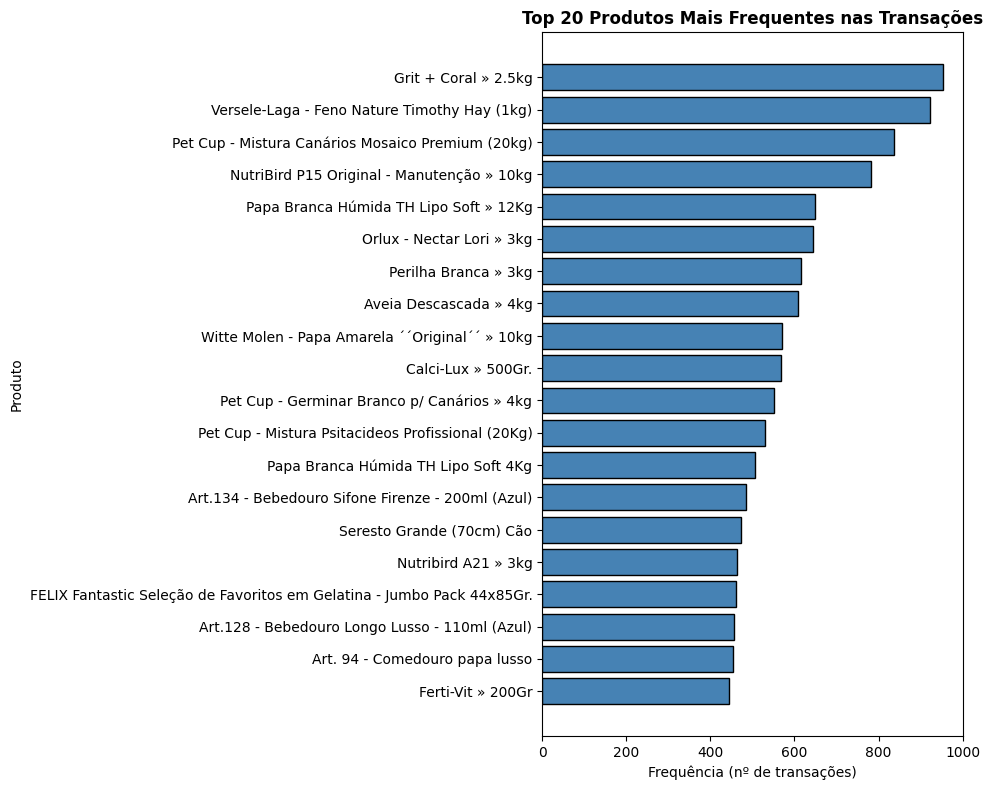

In [10]:
#Visualização: Top 20 produtos mais frequentes
plt.figure(figsize=(10, 8))

#Inverter a ordem para que o produto com maior frequência apareça no topo
top20 = freq_df.head(20).iloc[::-1]
plt.barh(top20['Nome do Produto'], top20['Frequência'], color='steelblue', edgecolor='black')

plt.title('Top 20 Produtos Mais Frequentes nas Transações', fontweight='bold')
plt.xlabel('Frequência (nº de transações)')
plt.ylabel('Produto')
plt.tight_layout()
plt.show()

O Top 20 dos produtos mais frequentes apresenta uma frequência que varia entre 953 (Grit + Coral » 2,5kg) e 444 (Ferti-Vit » 200Gr). Nesta análise incluiu-se também a métrica Support individual do produto representada por frequência do produto / total de transações, sendo variável entre 0,0079 (Ferti-Vit » 200Gr) e 0,0170 (Grit + Coral » 2,5kg).

Esta distribuição influencia a definição dos parâmetros do algoritmo Apriori, sendo que o:

- `min_support` deve ser suficientemente baixo (≤ 0,01) para ser possível identificar regras de produtos não massificados e suficientemente alto para assegurar significância estatística.
- `min_confidence` deve ser moderado, tendo em consideração que a transação usual tem apenas 2-3 produtos.
- `min_lift` deve ser elevado para assegurar que as regras de associação captadas são genuínas e não advêm da elevada frequência individual dos produtos.

## **5. Determinação dos parâmetros do Apriori**

Os parâmetros do Apriori (`MIN_SUPPORT`, `MIN_CONFIDENCE`, `MIN_LIFT`, `MIN_LENGTH` e `MAX_LENGTH`) são definidos com base na análise exploratória prévia.

In [11]:
#Número total de transações (denominador para cálculo de suporte)
n_transacoes = len(transactions)
print(f'Total de transações: {n_transacoes}')

#Equivalência min_support → nº de transações
#Se MIN_SUPPORT = 0.001 e há 55.971 transações, então uma regra precisa de ≥ 56 co-ocorrências
min_ocorrencias = 50
min_support_calc = min_ocorrencias / n_transacoes
print(f'min_support (>= {min_ocorrencias} co-ocorrências): {min_support_calc:.4f}')

#Parâmetros finais do Apriori
MIN_SUPPORT    = 0.001    #frequência mínima da regra (~56 co-ocorrências)
MIN_CONFIDENCE = 0.10     #probabilidade condicional mínima (10%)
MIN_LIFT       = 2.0      #força mínima da associação em relação ao acaso
MIN_LENGTH     = 2        #apenas pares de produtos
MAX_LENGTH     = 2        #limitar a pares para facilitar interpretação operacional

print(f'\nParâmetros definidos:')
print(f'  min_support    = {MIN_SUPPORT}')
print(f'  min_confidence = {MIN_CONFIDENCE}')
print(f'  min_lift       = {MIN_LIFT}')
print(f'  min_length     = {MIN_LENGTH}')
print(f'  max_length     = {MAX_LENGTH}')

Total de transações: 55971
min_support (>= 50 co-ocorrências): 0.0009

Parâmetros definidos:
  min_support    = 0.001
  min_confidence = 0.1
  min_lift       = 2.0
  min_length     = 2
  max_length     = 2


Os parâmetros definidos para o treino do modelo com o algoritmo Apriori são:
- `min_support` = 0,001
- `min_confidence` = 0,1
- `min_lift` = 2,0
- `min_length` = 2
- `max_length` = 2

## **6. Treino do modelo Apriori**

Neste passo é utilizada a função `apriori` da biblioteca `apyori` para treinar o modelo. A aplicação da função permite converter as regras numa lista para facilitar a visualização.

In [12]:
#Treinar o modelo Apriori com os parâmetros definidos
#O apyori devolve um generator - a conversão para list permite reutilizá-lo nas visualizações seguintes
rules = apriori(
    transactions = transactions,
    min_support   = MIN_SUPPORT,
    min_confidence= MIN_CONFIDENCE,
    min_lift      = MIN_LIFT,
    min_length    = MIN_LENGTH,
    max_length    = MAX_LENGTH
)

#converter as regras encontradas pela classe apriori numa lista para mais fácil visualização
results = list(rules)
print(f'Número de regras encontradas: {len(results)}')

Número de regras encontradas: 27


O treino do modelo identificou 27 regras de associação, que serão visualizadas e identificadas nos próximos passos.

## **7. Visualização dos resultados**

A validação da primeira regra identificada é essencial para compreender se ocorreram erros e para aceder a Support, Confidence e Lift. Cada `RelationRecord` contém os items e uma lista de `OrderedStatistic` com as métricas escolhidas.

In [13]:
#Estrutura da primeira regra
#Essencial para perceber como aceder aos campos na construção do dataframe
if len(results) > 0:
    print('Estrutura da primeira regra encontrada:')
    print(results[0])

Estrutura da primeira regra encontrada:
RelationRecord(items=frozenset({'Canhamo p/Aves 3kg', 'Aveia Descascada » 4kg'}), support=0.0010005181254578264, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Canhamo p/Aves 3kg'}), items_add=frozenset({'Aveia Descascada » 4kg'}), confidence=0.18481848184818483, lift=17.013939551849923)])


A primeira regra de associação identificada é composta pelos produtos "Canhamo p/Aves 3kg" e "Aveia Descascada » 4kg", sendo produtos associados ao segmento avícola. O `Support`obtido nesta regra foi 0,001, significando que são comprados em conjunto em apenas 0,10% das transações. Adicionalmente, esta associação apresenta um `Lift` elevado (17,01), traduzindo que na compra de um deles, a probabilidade de o outro ser comprado em conjunto é cerca de 17 vezes superior ao expectável caso as compras fossem independentes.

Analisando os dois sentidos da regra identificada, constata-se que os clientes que compram Canhamo, levam Aveia Descascada em 18,48% das situações.

Como tal, esta é uma associação muito forte e interessante para cross-selling ou criação de bundle orientado para o segmento de nicho de criadores de aves.

Validada a primeira regra, procede-se à listagem das 27 regras identificadas.

In [14]:
#Listagem de todas as regras com as métricas principais
#Iterar pelos RelationRecord e aceder à primeira OrderedStatistic (direção A → B)
for i, regra in enumerate(results, 1):
    items_base = list(regra.ordered_statistics[0].items_base)
    items_add  = list(regra.ordered_statistics[0].items_add)
    print(f'Regra {i}: {items_base[0]} -> {items_add[0]}')
    print(f'  Support:    {regra.support:.4f}  ({int(regra.support * n_transacoes)} transações)')
    print(f'  Confidence: {regra.ordered_statistics[0].confidence:.4f}  ({regra.ordered_statistics[0].confidence:.1%})')
    print(f'  Lift:       {regra.ordered_statistics[0].lift:.4f}')
    print('-' * 50)

Regra 1: Canhamo p/Aves 3kg -> Aveia Descascada » 4kg
  Support:    0.0010  (56 transações)
  Confidence: 0.1848  (18.5%)
  Lift:       17.0139
--------------------------------------------------
Regra 2: Aveia Descascada » 4kg -> Niger » 700Gr.
  Support:    0.0011  (64 transações)
  Confidence: 0.1053  (10.5%)
  Lift:       15.2240
--------------------------------------------------
Regra 3: Aveia Descascada » 4kg -> Perilha Branca » 3kg
  Support:    0.0014  (78 transações)
  Confidence: 0.1283  (12.8%)
  Lift:       11.6756
--------------------------------------------------
Regra 4: Calci-Lux » 500Gr. -> Ferti-Vit » 200Gr
  Support:    0.0016  (87 transações)
  Confidence: 0.1532  (15.3%)
  Lift:       19.3086
--------------------------------------------------
Regra 5: Canhamo p/Aves » 600Gr. -> Niger » 700Gr.
  Support:    0.0013  (72 transações)
  Confidence: 0.1925  (19.3%)
  Lift:       27.8428
--------------------------------------------------
Regra 6: Canhamo p/Aves » 600Gr. ->

Os resultados obtidos demonstram que os valores de Lift são bastante elevados (entre 6,74 e 231,73), na medida em que ultrapassam largamente o limite mínimo definido de 2,0. Em consequência, constata-se que os pares identificados representam associações genuínas caracterizadas por um número elevado de co-ocorrências em relação ao que seria expectável ao acaso em compras independentes.

## **8. DataFrame com regras ordenadas**

A criação de um dataframe facilita a ordenação, filtragem e exportação das regras identificadas. De forma a converter as regras num dataframe, utiliza-se a função `inspect`, que permite extrair as 5 colunas principais (LHS - produtos base, RHS - produtos "associados", Support, Confidence e Lift) e a coluna derivada `Support_abs` (Support × nº transações), que permite uma visualização rápida do número absoluto de co-ocorrências.

In [15]:
#Função para converter as regras do apyori num dataframe organizado
def inspect(results):
    lhs         = [tuple(result[2][0][0])[0] for result in results]    #Left Hand Side
    rhs         = [tuple(result[2][0][1])[0] for result in results]    #Right Hand Side
    supports    = [result[1] for result in results]                    #Support
    confidences = [result[2][0][2] for result in results]              #Confidence
    lifts       = [result[2][0][3] for result in results]              #Lift
    return list(zip(lhs, rhs, supports, confidences, lifts))

if len(results) > 0:
    resultsinDataFrame = pd.DataFrame(
        inspect(results),
        columns=['Left Hand Side', 'Right Hand Side', 'Support', 'Confidence', 'Lift']
    )
    #Adicionar coluna derivada com Support absoluto (número de transações conjuntas)
    resultsinDataFrame['Support_abs'] = (resultsinDataFrame['Support'] * n_transacoes).round(0).astype(int)
    print('Todas as regras encontradas:')
    print(resultsinDataFrame.to_string(index=False))
else:
    print('Nenhuma regra encontrada.')

Todas as regras encontradas:
                                                                Left Hand Side                                                                 Right Hand Side  Support  Confidence       Lift  Support_abs
                                                            Canhamo p/Aves 3kg                                                          Aveia Descascada » 4kg 0.001001    0.184818  17.013940           56
                                                        Aveia Descascada » 4kg                                                                  Niger » 700Gr. 0.001143    0.105263  15.223990           64
                                                        Aveia Descascada » 4kg                                                            Perilha Branca » 3kg 0.001394    0.128289  11.675594           78
                                                            Calci-Lux » 500Gr.                                                               Ferti-Vit » 20

In [16]:
# Exportação das regras de associação - histórico completo
resultsinDataFrame.to_csv(
    "/content/drive/MyDrive/regras_associacao_historico.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Regras de associação exportadas: "
    "regras_associacao_historico.csv"
)

Regras de associação exportadas: regras_associacao_historico.csv


Criado o dataframe, segue-se a apresentação das regras ordenadas pelas métricas Lift e Support.

In [17]:
#Ordenar pelo Lift (força da associação), realçando as associações mais não-triviais
print('\nRegras ordenadas por Lift (descendente):')
print(resultsinDataFrame.nlargest(n=len(resultsinDataFrame), columns='Lift').to_string(index=False))


Regras ordenadas por Lift (descendente):
                                                                Left Hand Side                                                                 Right Hand Side  Support  Confidence       Lift  Support_abs
                                                           Curva Plástico 12mm                                          Tê de 12mm para Bebedouros Automáticos 0.001572    0.807339 231.731263           88
                                                                Nekton E 70Gr.                                                                  Nekton S 75Gr. 0.001001    0.421053 198.039805           56
                                                        Torneira Passagem 12mm                                          Tê de 12mm para Bebedouros Automáticos 0.001126    0.567568 162.909356           63
                                             Deli Nature 20 - Serengeti (15kg)                                           Deli Nature 22 - Amaz

In [18]:
#Ordenar pelo Support (frequência), salientando as associações mais comuns
print('\nRegras ordenadas por Support (descendente):')
print(resultsinDataFrame.nlargest(n=len(resultsinDataFrame), columns='Support').to_string(index=False))


Regras ordenadas por Support (descendente):
                                                                Left Hand Side                                                                 Right Hand Side  Support  Confidence       Lift  Support_abs
GOURMET GOLD Mousse para Gato - Coelho, Vaca, Vitela e Borrego (Pack 24x85Gr.) GOURMET GOLD Tartelette para Gato - Frango, Vaca, Atum e Salmão (Pack 24x85Gr.) 0.002090    0.464286 102.309196          117
                                                     Seresto Grande (70cm) Cão                                                      Seresto Pequeno (38cm) Cão 0.001840    0.217759  54.655552          103
                                                                Niger » 700Gr.                                                            Perilha Branca » 3kg 0.001751    0.253230  23.046398           98
                                                          Grit + Coral » 2.5kg                               Pet Cup - Mistura Canários Mos

A visualização das regras numa perspetiva de análise da relação entre Confidence e Lift é possibilitada pela representação do Scatter Plot apresentado abaixo.

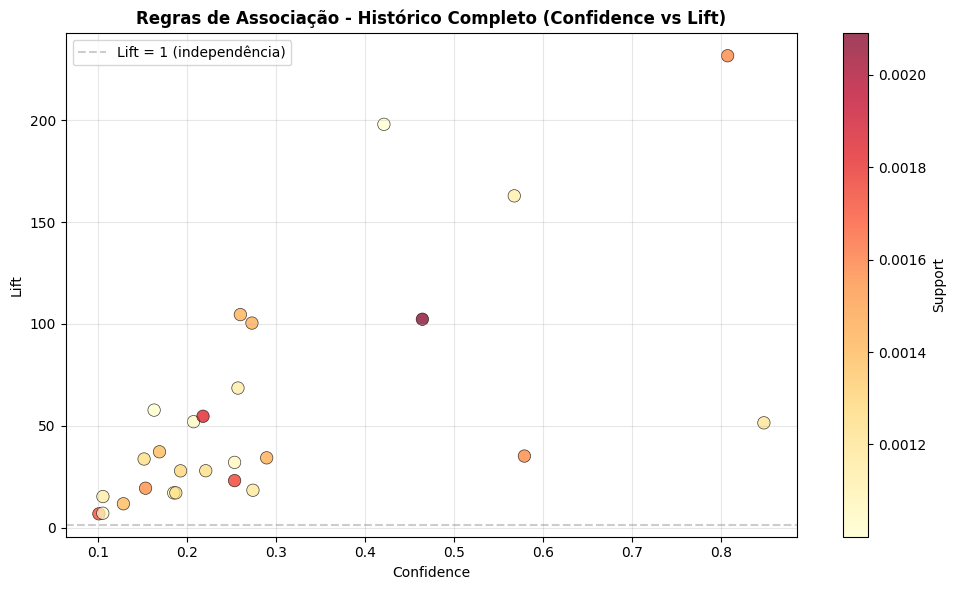

In [19]:
#Scatter plot Confidence vs Lift, em que cada ponto representa uma regra de associação
#O gradiente de cor está associado ao Support.
plt.figure(figsize=(10, 6))
plt.scatter(
    resultsinDataFrame['Confidence'],
    resultsinDataFrame['Lift'],
    c=resultsinDataFrame['Support'],
    cmap='YlOrRd',
    s=80,
    alpha=0.75,
    edgecolors='black',
    linewidths=0.5
)
plt.colorbar(label='Support')
plt.axhline(1, color='gray', ls='--', alpha=0.4, label='Lift = 1 (independência)')
plt.title('Regras de Associação - Histórico Completo (Confidence vs Lift)', fontweight='bold')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Foram identificadas 27 regras de associação com Lift variável entre 6,7 e 231,7. Estes valores elevados de Lift traduzem associações genuínas e não-triviais, indicando que os pares de produtos identificados ocorrem em conjunto entre dezenas a centenas de vezes mais do que seria expectável ao acaso se as compras fossem independentes.

As 27 regras organizam-se em **nove grupos temáticos**:

**Grupo 1 - Sementes puras para aves (6 regras) -** Associações entre Cânhamo, Niger, Perilha Branca e Aveia Descascada.

**Grupo 2 - Misturas para papagaios e psitacídeos (5 regras) -** Associações entre misturas de gamas equivalentes de diferentes marcas: Deli Nature (Serengeti/Amazonas Park), Loro Parque (Papagaio Africano/Amazonas), Pet Cup (Papagaios Africanos/Amazonas/Periquitos/Psitacideos Classic/Papagaios Standard).

**Grupo 3 - Alimentação especializada para canários (3 regras) -** Complementos (Grit + Coral, Easyyem Papa Amarela, Germinar Branco) sistematicamente adquiridos com a Mistura Canários Mosaico Premium da Pet Cup.

**Grupo 4 - Suplementos vitamínicos e minerais para aves (2 regras) -** Nekton E + Nekton S (par multivitamínico) e Calci-Lux + Ferti-Vit (cálcio + fertilidade), frequentemente comprados em conjunto na preparação da época reprodutiva.

**Grupo 5 - Ninhos para aves (1 regra) -** Ninho Plástico Grande com Grampo + Ninho Sisal Cosido - combinação de estruturas destinadas à reprodução.

**Grupo 6 - Componentes de bebedouros automáticos para aves (2 regras) -** Curva Plástico 12mm e Torneira Passagem 12mm associados ao Tê de 12mm. Refletem o padrão de compra conjunta de acessórios de montagem.

**Grupo 7 - Antiparasitários Seresto para cão e gato (3 regras) -** Coleiras Seresto em diferentes tamanhos (Grande Cão, Pequeno Cão, Gato) adquiridas em conjunto, refletindo o perfil de tutor com múltiplos animais de estimação de espécies e portes distintos.

**Grupo 8 - Comida húmida para gatos (3 regras) -** Combinações entre as gamas FELIX (Fantastic Jumbo Pack) e GOURMET GOLD (Mousse e Tartelette), traduzindo perfis de compra que privilegiam variedade de sabores ou tutores com vários gatos.

**Grupo 9 - Alimentação e enriquecimento para coelhos e roedores (2 regras) -** Feno Nature Timothy Hay (Versele-Laga) frequentemente associado a Cubetto Wood (madeira natural prensada para roer) e a Cuni Adult Complete (ração), representando o pack completo de alimentação e bem-estar para coelhos.

## **9. Análise de Sensibilidade - Limite de Suporte**

A análise anterior recorreu a `MIN_SUPPORT = 0,001`, que corresponde a pelo menos 56 co-ocorrências no histórico transacional completo. A realização de uma análise de sensibilidade, utilizando um `MIN_SUPPORT` menos restritivo (`MIN_SUPPORT = 0,0005`, equivalente a cerca de 28 co-ocorrências) permite avaliar o número de regras adicionais que serão identificadas e se essas regras estão associadas a temas relacionados com os identificados na análise principal.

In [20]:
#Análise de sensibilidade que permite testar um limite de suporte inferior
#Apenas o min_support é alterado, mantendo-se os restantes parâmetros iguais à análise principal
rules_s = apriori(
    transactions   = transactions,
    min_support    = 0.0005,          #limite mais permissivo (era 0.001)
    min_confidence = MIN_CONFIDENCE,
    min_lift       = MIN_LIFT,
    min_length     = MIN_LENGTH,
    max_length     = MAX_LENGTH
)
results_s = list(rules_s)

#Comparação em relação à análise principal
print(f'Regras com MIN_SUPPORT = 0.0005: {len(results_s)}')
print(f'Regras com MIN_SUPPORT = 0.001 (análise principal): {len(results)}')
print(f'Regras adicionais: {len(results_s) - len(results)}')

Regras com MIN_SUPPORT = 0.0005: 133
Regras com MIN_SUPPORT = 0.001 (análise principal): 27
Regras adicionais: 106


A diferença do limite aplicado a `MIN_SUPPORT` identifica um total de 133 regras de associação, representando 106 regras adicionais em relação às 27 que foram identificadas na análise principal. De forma a analisar as regras adicionais identificadas, procede-se à construção do dataframe e à sua ordenação por `Lift`.

In [21]:
#Construir DataFrame da análise de sensibilidade e ordenar por Lift
if len(results_s) > 0:
    resultsinDataFrame_s = pd.DataFrame(
        inspect(results_s),
        columns=['Left Hand Side', 'Right Hand Side', 'Support', 'Confidence', 'Lift']
    )
    resultsinDataFrame_s['Support_abs'] = (resultsinDataFrame_s['Support'] * n_transacoes).round(0).astype(int)

    print('Todas as 133 regras ordenadas por Lift (descendente):')
    print(resultsinDataFrame_s.nlargest(n=len(resultsinDataFrame_s), columns='Lift').to_string(index=False))

Todas as 133 regras ordenadas por Lift (descendente):
                                                                Left Hand Side                                                                 Right Hand Side  Support  Confidence       Lift  Support_abs
                                   Petfield - Lata Wetfood Dog Chicken » 410Gr                           Petfield - Lata Wetfood Dog Meat & Vegetables » 410Gr 0.000715    0.655738 764.631148           40
                                     Petfield - Lata Wetfood Dog Beef » 410Gr.                           Petfield - Lata Wetfood Dog Meat & Vegetables » 410Gr 0.000661    0.627119 731.259534           37
                                     Petfield - Lata Wetfood Dog Beef » 410Gr.                                     Petfield - Lata Wetfood Dog Chicken » 410Gr 0.000840    0.796610 730.935538           47
             GOURMET NATURE'S CREATIONS Frango, Espinafres e Tomate - 24x85Gr.           GOURMET NATURE'S CREATIONS Peixe Oceano, 

A visualização da totalidade das regras identificadas é apresentada no scatter plot abaixo, distinguindo as regras adicionais novas (106) das regras identificadas na análise principal (27).

In [22]:
# Ordenar as regras por Lift, do valor mais elevado para o mais baixo
resultsinDataFrame_s = resultsinDataFrame_s.sort_values(
    by='Lift',
    ascending=False
).reset_index(drop=True)

# Exportar as regras da análise de sensibilidade para CSV
resultsinDataFrame_s.to_csv(
    "/content/drive/MyDrive/regras_associacao_sensibilidade.csv",
    index=False,
    encoding="utf-8-sig"
)

# Confirmar a exportação do ficheiro
print("Regras da análise de sensibilidade exportadas para:")
print("/content/drive/MyDrive/regras_associacao_sensibilidade.csv")

Regras da análise de sensibilidade exportadas para:
/content/drive/MyDrive/regras_associacao_sensibilidade.csv


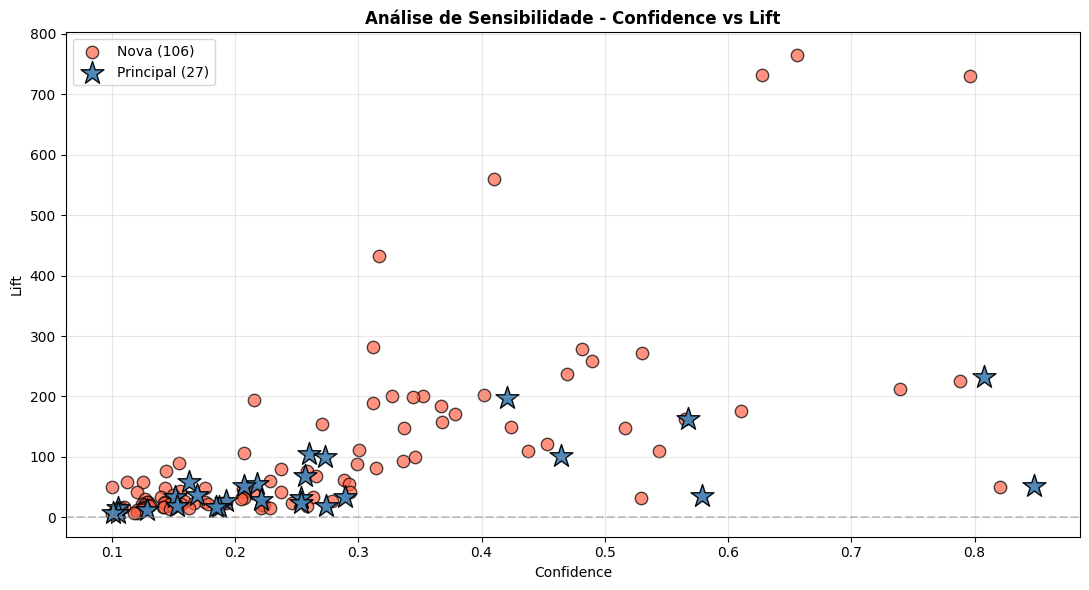

In [23]:
#Identificar regras já presentes na análise principal (ambas as direções A→B e B→A)
pares = set(zip(resultsinDataFrame['Left Hand Side'], resultsinDataFrame['Right Hand Side']))
pares |= {(b, a) for a, b in pares}    #adicionar direção inversa para comparação simétrica

#Marcar cada regra da análise de sensibilidade como 'principal' ou 'nova'
mask = resultsinDataFrame_s.apply(
    lambda r: (r['Left Hand Side'], r['Right Hand Side']) in pares, axis=1
)

#Plot - círculos vermelhos (novas) + estrelas azuis (análise principal)
plt.figure(figsize=(11, 6))
plt.scatter(resultsinDataFrame_s[~mask]['Confidence'], resultsinDataFrame_s[~mask]['Lift'],
            c='tomato', marker='o', s=80, alpha=0.7, edgecolors='black',
            label=f'Nova ({(~mask).sum()})')
plt.scatter(resultsinDataFrame_s[mask]['Confidence'], resultsinDataFrame_s[mask]['Lift'],
            c='steelblue', marker='*', s=300, alpha=0.95, edgecolors='black',
            label=f'Principal ({mask.sum()})')
plt.axhline(1, color='gray', ls='--', alpha=0.4)
plt.title('Análise de Sensibilidade - Confidence vs Lift', fontweight='bold')
plt.xlabel('Confidence'); plt.ylabel('Lift')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

A redução do limite de Support de 0,001 para 0,0005 permite a captação de regras com apenas cerca de 28 co-ocorrências ao invés das 56 da análise principal. Os resultados da análise de sensibilidade demonstram um aumento de 106 regras adicionais face às 27 regras originais, que se mantêm intactas.

A análise mais aprofundada às regras novas indica uma contínua predominância por associações no segmento de aves, nomeadamente, ao nível de produtos relacionados com acessórios, misturas, suplementos, sementes, ninhos, mas incluem-se associações de produtos de alimentação seca e húmida para cães e gatos, sendo algo que não se tinha verificado anteriormente.

Estes resultados permitem concluir que, embora a prioridade seja a implementação das 27 regras anteriormente identificadas, existe igualmente um elevado potencial de cross-sell relacionado com produtos que evidenciam menor frequência de compra conjunta.

## **10. Síntese**

A aplicação do algoritmo Apriori envolvendo todo o histórico transacional da empresa nos últimos 10 anos identificou 27 regras de associação com Support ≥ 0,001, Confidence ≥ 0,10 e Lift ≥ 2,0, organizadas em nove grupos temáticos coerentes.

Os valores de Lift variam entre 6,7 e 231,7, estando significativamente acima do limite mínimo de 2,0. Como tal, os pares de produtos identificados ocorrem em conjunto dezenas a centenas de vezes mais do que o expectável numa situação de acaso, assegurando que estas associações são genuínas e não-triviais.

Os nove grupos temáticos identificados são:
- **Grupo 1 - Sementes puras para aves (6 regras)**
- **Grupo 2 - Misturas para papagaios e psitacídeos (5 regras)**
- **Grupo 3 - Alimentação especializada para canários (3 regras)**
- **Grupo 4 - Suplementos vitamínicos e minerais para aves (2 regras)**
- **Grupo 5 - Ninhos para aves (1 regra)**
- **Grupo 6 - Componentes de bebedouros automáticos para aves (2 regras)**
- **Grupo 7 - Antiparasitários Seresto para cão e gato (3 regras)**
- **Grupo 8 - Comida húmida para gatos (3 regras)**
- **Grupo 9 - Alimentação e enriquecimento para coelhos (2 regras)**

A análise de sensibilidade realizada evidencia que as 27 regras principais são um subconjunto integral das 133 regras obtidas ao aplicar um limite mais permissivo (0,0005).

No próximo notebook é utilizado o dataframe `resultsinDataFrame` para executar o algoritmo Apriori sobre os últimos 12 meses, permitindo compreender os padrões de compra mais recente e a evolução do catálogo de produtos da empresa para realizar uma análise temporal comparativa. Este tipo de análise é útil para a identificação de regras persistentes, emergentes e descontinuadas.
